# 3. Calidad de datos en entrenamiento: faltantes, outliers y sesgo

*Autores: María Carolina Cantillo Orozco (200179105) y Juan Camilo Oñoro Araujo (200177329)*

Completa la parte de **calidad de datos** de la Sección 1 del rubric que sí
implica decisiones de modelado (cómo imputar, cómo tratar outliers). Por eso
se hace **solo con entrenamiento**:

- Valores faltantes: **patrón** (matriz de nulos) y **mecanismo**
  (MCAR / MAR / MNAR) con evidencia.
- Outliers univariados: detección (IQR de Tukey) y tratamiento.
- Sesgo de muestreo y representatividad: quién queda fuera del modelo.

In [1]:
# Configuración y carga de SOLO entrenamiento. Desde este capítulo todo lo que
# pueda convertirse en una decisión de modelado (imputación, outliers) se calcula
# sin mirar test, para evitar fuga de información (orden de trabajo del rubric).
import sys
import warnings
from pathlib import Path

# Raíz del libro en sys.path para importar src/ desde notebooks/ o desde la raíz.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
# Regresión logística + CV: se usan para intentar PREDECIR el indicador de nulo
# (diagnóstico MCAR vs. MAR), no para predecir el estrato.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src import config as C       # listas de variables, SEED, guardar_decision
from src import estadistica as E  # V de Cramér y demás pruebas del EDA
from src import graficos as G
from src import particion as P    # cargar_particion lee el dataset del cap. 2

G.estilo()
C.aviso_sintetico()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# solo="train" filtra particion == "train": el conjunto de prueba no se abre aquí.
train = P.cargar_particion(solo="train")
print(f"Filas de entrenamiento: {len(train):,}")

Filas de entrenamiento: 218,870


## 3.1 Valores faltantes

### Patrón

In [2]:
# Patrón de faltantes en train: conteo y % de nulos por variable, más una columna
# que indica si el nulo proviene sobre todo de una regla del cap. 1 (valor
# imposible: año 1512, piso 99...; o incoherencia dentro de la fila) o si ya venía
# vacío en el origen.
vars_nulos = C.NUMERICAS + C.CATEGORICAS
tabla_nulos = pd.DataFrame({
    "n nulos": train[vars_nulos].isna().sum(),
    "% nulos": 100 * train[vars_nulos].isna().mean(),
}).sort_values("% nulos", ascending=False)
# Criterio: si al menos la mitad de los nulos de la variable tiene su bandera
# flag_imposible_* (rango de dominio, paso 4) o flag_incoherente_* (coherencia
# dentro de la fila, paso 5) activa, ese es el origen principal. 'antiguedad'
# no tiene bandera propia: hereda la de 'anio_construccion', de donde se deriva.
# max(1, n) evita que una variable sin nulos (n = 0) cuente como "valor imposible".
tabla_nulos["origen principal"] = [
    "valor imposible -> NaN" if f"flag_imposible_{v}" in train and train[f"flag_imposible_{v}"].sum() >= 0.5 * max(1, n)
    else ("incoherencia en la fila -> NaN" if f"flag_incoherente_{v}" in train
          and train[f"flag_incoherente_{v}"].sum() >= 0.5 * max(1, n)
          else ("año imposible -> NaN" if v == "antiguedad" and train["flag_imposible_anio_construccion"].sum() >= 0.5 * max(1, n)
                else "faltante en origen"))
    for v, n in zip(tabla_nulos.index, tabla_nulos["n nulos"])]
tabla_nulos

,n nulos,% nulos,origen principal
total_habitaciones,271,0.124,incoherencia en la fila -> NaN
planta_ubicacion,237,0.108,valor imposible -> NaN
antiguedad,129,0.059,año imposible -> NaN
total_banios,28,0.013,incoherencia en la fila -> NaN
total_plantas,1,0.000,valor imposible -> NaN
area_catastral_terreno,0,0.000,faltante en origen
area_construida,0,0.000,faltante en origen
altura,0,0.000,faltante en origen
tipo_vivienda,0,0.000,faltante en origen
uso,0,0.000,faltante en origen


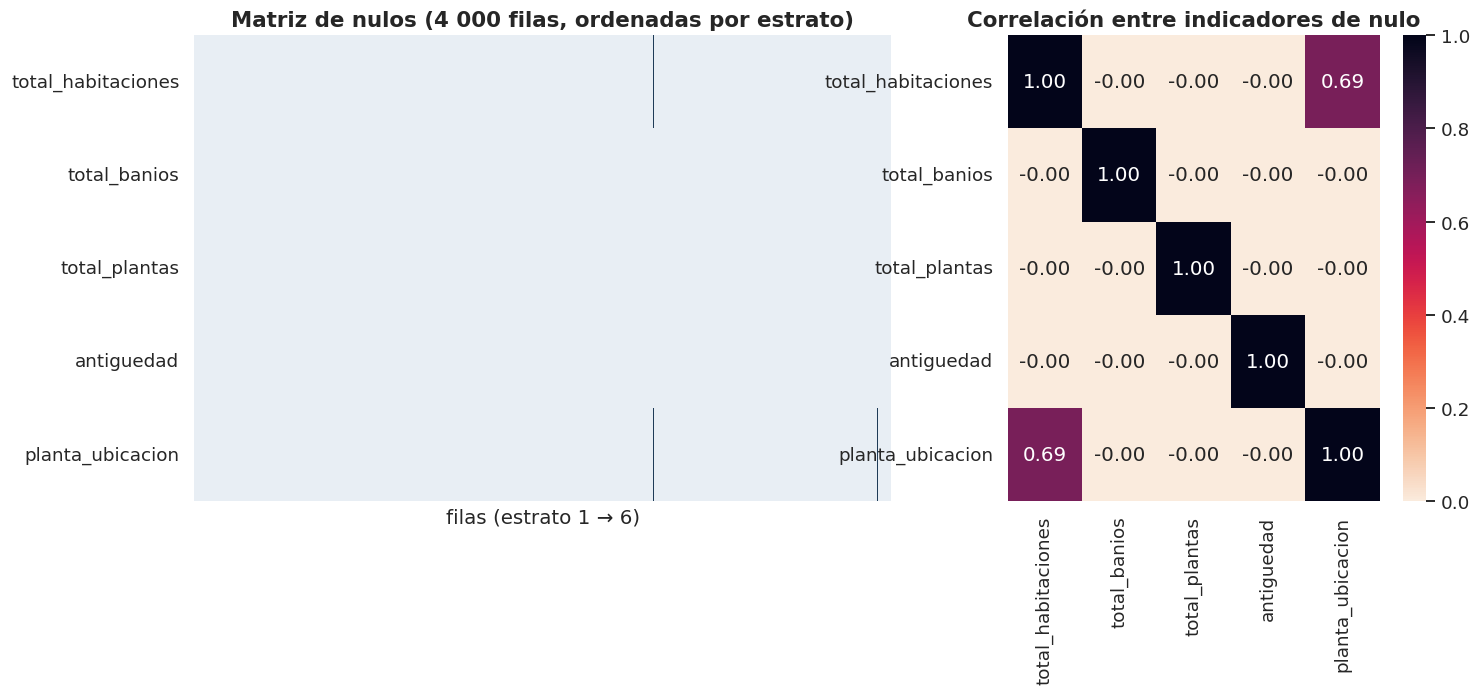

In [3]:
# Figura del patrón de nulos. Izquierda: matriz de nulos (oscuro = falta el dato)
# en 4 000 filas ordenadas por estrato; si los nulos se agrupan en una franja de
# estrato, el faltante no es al azar. Derecha: correlación entre indicadores de
# nulo (valores altos = variables que faltan juntas, en los mismos registros).
con_nulos = [c for c in vars_nulos if train[c].isna().any()]   # solo las que tienen nulos
# Submuestra con semilla fija solo para que la matriz sea legible; ordenada por estrato.
muestra = train.sample(min(4000, len(train)), random_state=C.SEED).sort_values(C.OBJETIVO)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [3, 2]})
if con_nulos:
    sns.heatmap(muestra[con_nulos].isna().T, cbar=False, cmap=["#e8eef4", "#1f3b57"], ax=axes[0],
                xticklabels=False)
    axes[0].set_title("Matriz de nulos (4 000 filas, ordenadas por estrato)")
    axes[0].set_xlabel("filas (estrato 1 → 6)")
    # Indicadores 0/1 de nulo en TODO train (no en la submuestra) para la correlación.
    co = train[con_nulos].isna().astype(float)
    sns.heatmap(co.corr() if len(con_nulos) > 1 else co.corr(), annot=True, fmt=".2f", cmap="rocket_r",
                vmin=0, vmax=1, ax=axes[1])
    axes[1].set_title("Correlación entre indicadores de nulo")
G.guardar(fig, "03_matriz_nulos")
plt.show()

### Mecanismo (MCAR / MAR / MNAR)

Con cientos de miles de filas la prueba de Little rechaza MCAR ante
cualquier diferencia mínima, así que se usan tres evidencias complementarias
y se interpreta la **magnitud**:

1. **Faltante vs. estrato:** chi² y V de Cramér entre el indicador de nulo y
   el objetivo. V ≈ 0 es compatible con MCAR respecto al objetivo.
2. **Registros completos vs. incompletos:** diferencia de medias estandarizada
   (SMD) en las demás variables. |SMD| < 0.1 se considera despreciable.
3. **¿Se puede predecir el faltante?** Regresión logística del indicador de
   nulo con las variables observadas (AUC por validación cruzada). AUC ≈ 0.5
   → MCAR plausible; AUC claramente > 0.5 → el faltante depende de variables
   observadas (**MAR**). MNAR (depende del propio valor no observado) no se
   puede probar con los datos: se argumenta con conocimiento del dominio.

In [4]:
# Diagnóstico del mecanismo de faltantes con tres evidencias por variable:
# (1) V de Cramér entre el indicador de nulo y el estrato, (2) diferencia de medias
# estandarizada (SMD) entre registros con y sin nulo, y (3) AUC de una regresión
# logística que intenta predecir el nulo a partir de variables observadas.
# Variables observadas que se usan como "explicativas" del faltante.
observadas = ["area_construida", "total_habitaciones", "total_banios", "total_plantas", "x_km", "y_km"]
# Régimen del predio en one-hot (con "NA" como categoría) para añadirlo a la logística.
dummies_cond = pd.get_dummies(train["condicion_predio"].fillna("NA"), prefix="cond", dtype=float)
filas = []
for v in con_nulos:
    ind = train[v].isna()          # indicador de nulo de la variable v (True = falta)
    if ind.sum() < 30:
        continue                   # con menos de 30 nulos no hay base para ningún diagnóstico
    # (1) Asociación nulo ~ estrato: V ≈ 0 es compatible con MCAR respecto al objetivo.
    cv = E.cramers_v(ind, train[C.OBJETIVO])
    # (2) SMD de cada variable observada entre filas con nulo (a) y sin nulo (b),
    # usando la desviación estándar combinada; |SMD| < 0.1 se considera despreciable.
    smd = {}
    for o in observadas:
        if o == v:
            continue               # no se compara la variable consigo misma
        a, b = train.loc[ind, o].dropna(), train.loc[~ind, o].dropna()
        sd = np.sqrt((a.var() + b.var()) / 2)
        smd[o] = (a.mean() - b.mean()) / sd if sd > 0 else np.nan
    # (3) Matriz de predictores del nulo: observadas (sin v) imputadas con su mediana
    # de train, solo para este diagnóstico, más las dummies de condición del predio.
    X = pd.concat([train[[o for o in observadas if o != v]].fillna(train[[o for o in observadas if o != v]].median()),
                   dummies_cond], axis=1)
    # Submuestra de hasta 60 000 filas (semilla fija) para acotar el tiempo de cómputo.
    sub = np.random.default_rng(C.SEED).choice(len(X), min(60_000, len(X)), replace=False)
    # AUC promedio en CV de 3 folds; el escalado va dentro del pipeline para que se
    # ajuste en cada fold. AUC ≈ 0.5 -> MCAR plausible; AUC alto -> MAR.
    auc = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=500)),
                          X.iloc[sub], ind.iloc[sub], cv=3, scoring="roc_auc").mean()
    # Variable con la mayor |SMD| (los NaN se ignoran asignándoles -1 en la comparación).
    smd_max = max(smd.items(), key=lambda t: abs(t[1]) if pd.notna(t[1]) else -1)
    # Se guarda también la tasa de nulo en cada estrato (1/2/3/4/5/6) para leerla a ojo.
    filas.append({"variable": v, "n nulos": int(ind.sum()), "% nulos": 100 * ind.mean(), "V (nulo~estrato)": cv["V"],
                  "|SMD| máx.": abs(smd_max[1]), "en variable": smd_max[0], "AUC predecir nulo": auc,
                  "tasa de nulo por estrato (%)": " / ".join(f"{100 * r:.1f}" for r in
                                                              ind.groupby(train[C.OBJETIVO]).mean())})
mecanismo = pd.DataFrame(filas).set_index("variable") if filas else pd.DataFrame()


# Regla de lectura que combina las tres evidencias. MCAR solo si las tres son
# débiles a la vez; en otro caso el faltante depende de lo observado (MAR). MNAR no
# se puede probar con los datos y se argumenta con conocimiento del dominio.
def lectura_mecanismo(r):
    if r["n nulos"] < 100:
        return "muy pocos casos (<100): no evaluable; proviene de valores imposibles"
    if r["AUC predecir nulo"] < 0.6 and r["V (nulo~estrato)"] < 0.05 and r["|SMD| máx."] < 0.1:
        return "compatible con MCAR"
    return "MAR (depende de variables observadas)"


if len(mecanismo):
    mecanismo["lectura"] = mecanismo.apply(lectura_mecanismo, axis=1)
mecanismo

,n nulos,% nulos,V (nulo~estrato),|SMD| máx.,en variable,AUC predecir nulo,tasa de nulo por estrato (%),lectura
variable,,,,,,,,
total_habitaciones,271,0.124,0.037,1.634,area_construida,0.997,0.1 / 0.0 / 0.3 / 0.0 / 0.1 / 0.0,MAR (depende de variables observadas)
antiguedad,129,0.059,0.052,1.961,y_km,0.971,0.0 / 0.0 / 0.0 / 0.3 / 0.0 / 0.0,MAR (depende de variables observadas)
planta_ubicacion,237,0.108,0.041,1.645,total_habitaciones,0.963,0.0 / 0.0 / 0.3 / 0.0 / 0.1 / 0.2,MAR (depende de variables observadas)


```{admonition} Interpretación y decisión
:class: note
- **Los faltantes son mínimos.** En train, la variable con más nulos es
  `total_habitaciones` con **271 (0.12 %)**; luego `planta_ubicacion` con
  237 (0.11 %), `antiguedad` con 129 (0.06 %), baños con 28 (0.01 %) y
  plantas con 1. Todos provienen de las reglas del capítulo 1, no de celdas
  vacías en origen: pisos codificados (97–99) y años centinela (paso 4), e
  incoherencias dentro de la fila (paso 5). La columna "origen principal"
  lo confirma: planta y plantas salen como "valor imposible", antigüedad
  como "año imposible", y habitaciones y baños como "incoherencia en la
  fila" (bandera `flag_incoherente_*`), igual que en el dataset completo,
  donde todos los nulos de habitaciones (0.107 %) y de baños (0.012 %) son
  incoherencias (cap. 1, columna "de ellos, por incoherencia"). Las
  variables sin nulos aparecen como "faltante en origen" solo porque es la
  etiqueta por defecto de la tabla.
- **Baños** tiene menos de 30 nulos y queda fuera del diagnóstico de
  mecanismo: no hay base para evaluarlo.
- **Habitaciones** es **MAR**, pero por construcción: su nulo se predice casi
  perfectamente (AUC = 0.997) y la mayor diferencia está en
  `area_construida` (|SMD| = 1.63), porque la regla anula las habitaciones
  cuando el área por habitación es menor de 6 m². El faltante depende de
  una variable observada (el área), no del azar.
- **Piso de ubicación** es **MAR**: su nulo se predice casi perfectamente
  (AUC = 0.963) y la mayor diferencia está en `total_habitaciones`
  (|SMD| = 1.65); el 0.3 % de las unidades de estrato 3 tiene un código de
  piso, frente a ≤ 0.2 % en el resto. El código se concentra en ciertos
  edificios o sectores, no al azar.
- **Antigüedad** es **MAR**: su nulo se predice casi perfectamente con las
  variables observadas (AUC = 0.971) y la mayor diferencia estandarizada
  está en `y_km` (|SMD| = 1.96), es decir, los años faltantes se concentran
  en una zona concreta de la ciudad (0.3 % de nulos en estrato 4 frente a
  ~0 % en el resto). Los 129 años imposibles del dataset completo (cap. 1)
  caen todos en train, lo que es coherente con esa concentración espacial.
  No es un faltante al azar: parece un proyecto o un sector cuyo año no se
  registró.
- **Decisión:** mediana + indicador de faltante, dentro del Pipeline (el
  indicador deja que el modelo use "no tener el dato" si eso informa el
  estrato). Con tan pocos nulos (< 1 %), la elección del imputador apenas afecta
  al modelo; lo importante es no aprenderlo con test. Ninguna variable
  supera el 30 % de faltantes, así que, siguiendo las notas del curso
  (9.10.4.1.4), **no se elimina ninguna variable** por faltantes.
```

In [5]:
# Registro de decisiones de imputación en decisiones_eda.json, con su motivo. El
# modelo base (cap. 10) lee este archivo, de modo que cada paso del Pipeline queda
# rastreado al hallazgo de este capítulo. La imputación se ajusta dentro del
# Pipeline, es decir, solo con los datos de entrenamiento de cada fold.
C.guardar_decision(
    "imputacion_numericas", "mediana + indicador de faltante (SimpleImputer(add_indicator=True)), dentro del Pipeline",
    "Faltantes < 30 % en todas las variables; mecanismo MAR/informativo según AUC y SMD (cap. 3.1); "
    "la mediana es robusta a la asimetría fuerte de áreas y conteos.")
C.guardar_decision(
    "imputacion_categoricas", "categoría explícita 'faltante'",
    "Conserva la información de que el dato no existía, sin inventar una categoría real.")

[decisión registrada] imputacion_numericas = mediana + indicador de faltante (SimpleImputer(add_indicator=True)), dentro del Pipeline
   motivo: Faltantes < 30 % en todas las variables; mecanismo MAR/informativo según AUC y SMD (cap. 3.1); la mediana es robusta a la asimetría fuerte de áreas y conteos.
[decisión registrada] imputacion_categoricas = categoría explícita 'faltante'
   motivo: Conserva la información de que el dato no existía, sin inventar una categoría real.


## 3.2 Outliers univariados (IQR de Tukey)

Los valores **imposibles** ya se convirtieron en NaN (capítulo 1). Lo que
queda son valores **extremos pero plausibles**: una casa de 8 baños, un lote
muy grande. Se cuantifican con la regla de Tukey
$[Q_1 - 1.5\,IQR,\ Q_3 + 1.5\,IQR]$ y con un criterio más estricto
($3\,IQR$, "outliers lejanos").

In [6]:
# Outliers univariados con la regla de Tukey (1.5·IQR) y con el criterio de
# "outliers lejanos" (3·IQR), calculados solo con train. Se reportan también p99.9
# y máximo porque el p99.9 es el umbral de la winsorización que se decide después.
nums = [c for c in C.NUMERICAS if c in train]
filas = []
for c in nums:
    v = train[c].dropna()
    q1, q3 = v.quantile([.25, .75])
    iqr = q3 - q1
    # Fracción de valores fuera de las vallas de Tukey (1.5·IQR) y de las lejanas (3·IQR).
    f15 = ((v < q1 - 1.5 * iqr) | (v > q3 + 1.5 * iqr)).mean()
    f30 = ((v < q1 - 3 * iqr) | (v > q3 + 3 * iqr)).mean()
    filas.append({"variable": c, "Q1": q1, "Q3": q3, "IQR": iqr, "lím. sup. 1.5·IQR": q3 + 1.5 * iqr,
                  "% fuera 1.5·IQR": 100 * f15, "% fuera 3·IQR": 100 * f30,
                  "p99.9": v.quantile(.999), "máx": v.max()})
outliers = pd.DataFrame(filas).set_index("variable")
outliers

,Q1,Q3,IQR,lím. sup. 1.5·IQR,% fuera 1.5·IQR,% fuera 3·IQR,p99.9,máx
variable,,,,,,,,
area_construida,54.000,115.000,61.000,206.500,5.973,2.115,692.131,"1,971.000"
area_catastral_terreno,30.600,144.500,113.900,315.350,4.833,1.297,"5,193.000","36,022.000"
total_habitaciones,2.000,3.000,1.000,4.500,5.598,0.969,12.000,20.000
total_banios,1.000,2.000,1.000,3.500,3.345,0.265,6.000,15.000
total_plantas,1.000,1.000,0.000,1.000,11.144,11.144,12.000,35.000
antiguedad,8.000,28.000,20.000,58.000,1.380,0.088,86.000,94.000
planta_ubicacion,1.000,4.000,3.000,8.500,7.980,1.356,20.000,41.000
altura,3.000,3.000,0.000,3.000,0.312,0.312,3.000,9.000


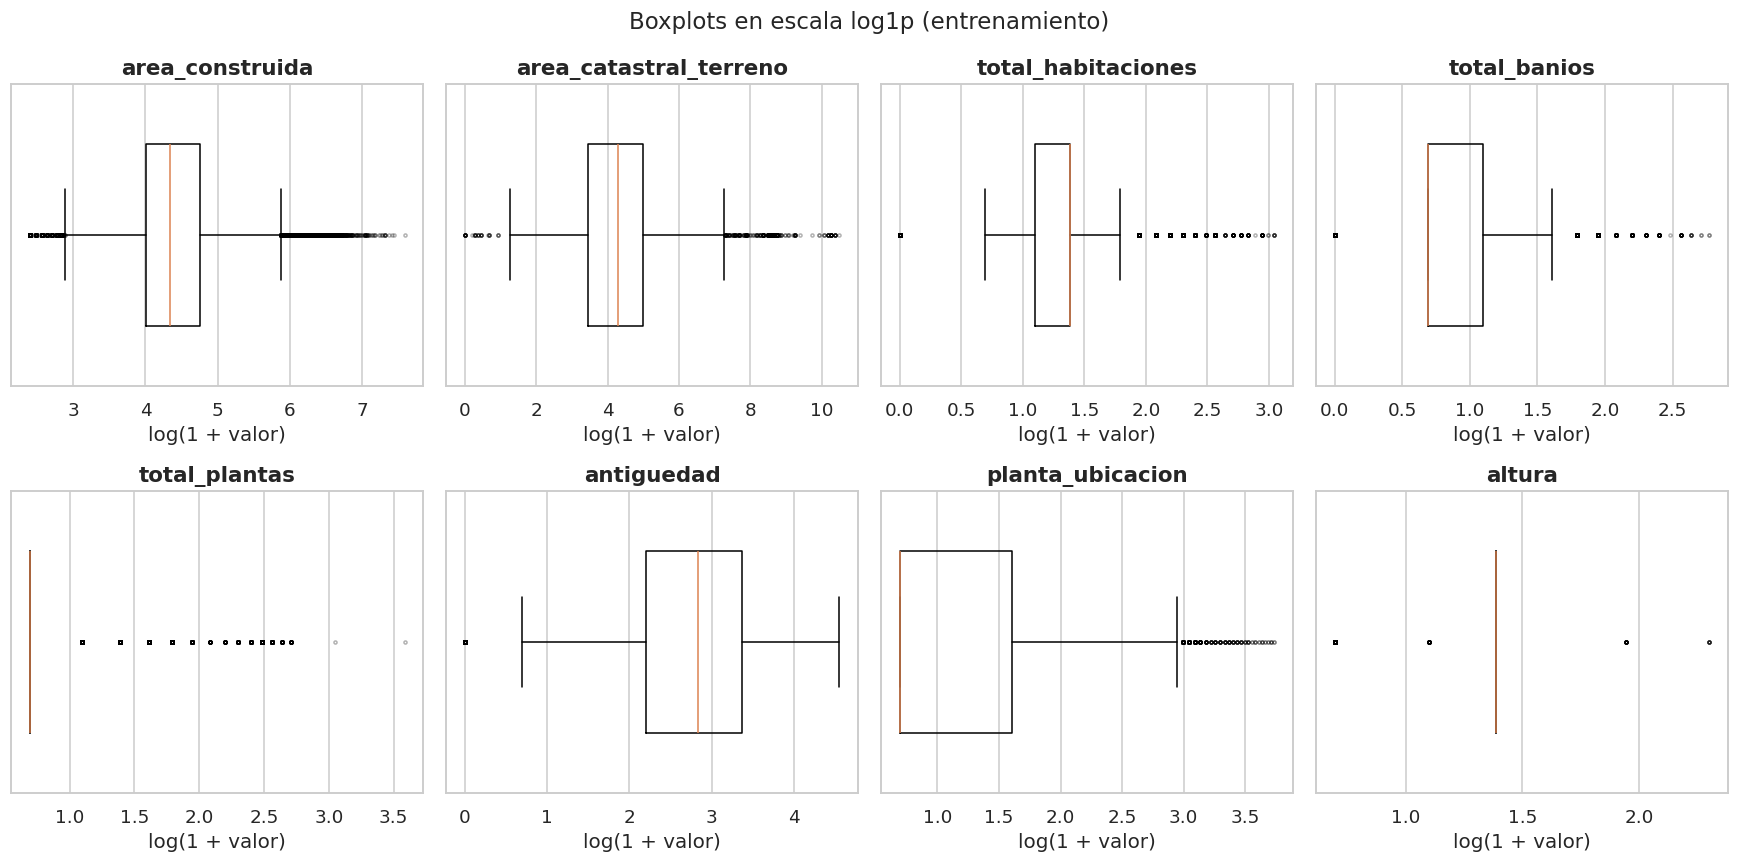

In [7]:
# Boxplots de cada variable numérica de train en escala log(1 + x). El logaritmo
# comprime las colas largas para poder ver el cuerpo de la distribución y los
# extremos en la misma figura; los puntos sueltos son los outliers de Tukey.
fig, axes = plt.subplots(2, (len(nums) + 1) // 2, figsize=(16, 8))
for ax, c in zip(axes.ravel(), nums):
    v = train[c].dropna()
    # clip(lower=0) evita log de negativos; los puntos atípicos se dibujan pequeños.
    ax.boxplot(np.log1p(v.clip(lower=0)), orientation="horizontal", widths=0.6,
               flierprops={"markersize": 2, "alpha": 0.3})
    ax.set_title(c)
    ax.set_xlabel("log(1 + valor)")
    ax.set_yticks([])
# Se ocultan los paneles sobrantes de la grilla si el número de variables es impar.
for ax in axes.ravel()[len(nums):]:
    ax.axis("off")
fig.suptitle("Boxplots en escala log1p (entrenamiento)")
fig.tight_layout()
G.guardar(fig, "03_boxplots_outliers")
plt.show()

```{admonition} Interpretación y decisión
:class: note
- La regla de Tukey marca entre **3 % y 6 %** de las filas en áreas,
  habitaciones y baños (8 % en piso de ubicación), pero muy pocas son "lejanas" (3·IQR): 2.1 % en
  área construida, 1.3 % en terreno, < 1 % en habitaciones y baños. Las
  distribuciones son muy **asimétricas a la derecha**; esos puntos son
  viviendas grandes, no errores.
- En `total_plantas` y `altura` la regla es **inservible**: su IQR es 0 (Q1 =
  Q3 = 1 planta; Q1 = Q3 = 3 m). En plantas, *cualquier* casa de dos pisos
  queda marcada como outlier (11.1 % de train); en altura, cualquier valor
  distinto de 3 (0.3 %). Es un ejemplo de por qué no se debe eliminar filas
  con una regla automática sin mirarla.
- Los máximos que quedan son grandes pero posibles: 1 971 m² construidos,
  36 022 m² de terreno, 20 habitaciones, 15 baños y 35 plantas. Los de
  área construida, habitaciones y baños quedan dentro de los topes de la
  regla de registros agregados del cap. 1 (paso 2c: más de 2 000 m², 20
  habitaciones o 15 baños es un edificio entero en una fila). El p99.9 (los
  umbrales que usará la winsorización) está en 692 m² de área construida,
  5 193 m² de terreno, 12 habitaciones, 6 baños y 12 plantas.
- En `planta_ubicacion`, los códigos 97–99 ya se trataron como faltantes
  (cap. 1, techo del rango en 60): el p99.9 queda en 20 y el máximo en 41,
  un piso real de las torres más altas, no un código.
- **Decisión:** no se elimina ninguna fila por ser outlier estadístico, porque
  el área construida crece con el estrato (mediana de 54 m² en estrato 1
  frente a 152 m² en estrato 6, cap. 6): las viviendas más grandes pesan más
  en las clases altas, que ya son minoritarias. Su influencia en el modelo
  lineal se reduce con (i) `log1p`
  en las variables muy asimétricas (cap. 5) y (ii) **winsorización** a los
  percentiles 0.1 y 99.9 **aprendidos en train** dentro del Pipeline.
- Los outliers **multivariados** (combinaciones raras) se revisan en el
  capítulo 7.
```

In [8]:
# Se registra la decisión de winsorizar a los percentiles 0.1 y 99.9 en lugar de
# eliminar filas. Los cuantiles se aprenden en train dentro del Pipeline (clase de
# recorte de modelo.py), así que test nunca influye en los umbrales.
C.guardar_decision("winsorizacion_cuantiles", [0.001, 0.999],
                   "Colas largas plausibles (cap. 3.2): se recortan a p0.1/p99.9 de train dentro del "
                   "Pipeline en lugar de eliminar filas, para no sesgar las clases altas.")

[decisión registrada] winsorizacion_cuantiles = [0.001, 0.999]
   motivo: Colas largas plausibles (cap. 3.2): se recortan a p0.1/p99.9 de train dentro del Pipeline en lugar de eliminar filas, para no sesgar las clases altas.


## 3.3 Sesgo de muestreo y representatividad

¿A quién deja fuera el modelo? Se comparan las filas **con** coordenadas
(población de modelado) contra las filas **sin** coordenadas, que no se
pudieron ubicar (predios informales, capítulo 1). Para no mirar el conjunto
de prueba, la comparación usa solo train frente a las filas no ubicables.

In [9]:
# Sesgo de cobertura: compara la distribución del estrato en la población modelada
# (solo train, para no mirar test) con la de las filas sin coordenadas, que quedan
# fuera del modelo. Si difieren mucho, el modelo no representa a toda la ciudad.
ruta_sin = C.CARPETA_PROCESADOS / "sin_coordenadas.parquet"
# Se lee el formato con que se guardó en el cap. 2 (parquet o, si no, CSV).
sin = pd.read_parquet(ruta_sin) if ruta_sin.exists() else pd.read_csv(ruta_sin.with_suffix(".csv"))
# % de cada estrato dentro de cada grupo; fillna(0) por si a un grupo le falta un estrato.
comp = pd.concat({
    "modelado (train)": train[C.OBJETIVO].value_counts(normalize=True),
    "sin coordenadas": sin[C.OBJETIVO].value_counts(normalize=True),
}, axis=1).sort_index().fillna(0).mul(100)
comp.index = [C.NOMBRES_CLASES[i] for i in comp.index]
# V de Cramér entre "grupo" (modelado / sin coordenadas) y estrato: se apilan ambos
# grupos en una sola tabla para medir la fuerza de la asociación (0 = sin sesgo).
cv_sesgo = E.cramers_v(pd.concat([pd.Series("modelado", index=train.index), pd.Series("sin", index=sin.index)],
                                 ignore_index=True),
                       pd.concat([train[C.OBJETIVO], sin[C.OBJETIVO]], ignore_index=True))
print(f"V de Cramér (grupo ~ estrato) = {cv_sesgo['V']:.3f}")
comp

V de Cramér (grupo ~ estrato) = 0.424


,modelado (train),sin coordenadas
1 Bajo-bajo,25.542,66.315
2 Bajo,19.866,30.187
3 Medio-bajo,25.984,3.099
4 Medio,16.857,0.089
5 Medio-alto,6.091,0.269
6 Alto,5.661,0.041


In [10]:
# Misma comparación para el régimen del predio (condicion_predio): sirve para
# explicar POR QUÉ faltan coordenadas (se espera que dominen los predios informales).
cond = pd.concat({
    "modelado (train)": train["condicion_predio"].value_counts(normalize=True),
    "sin coordenadas": sin["condicion_predio"].value_counts(normalize=True),
}, axis=1).fillna(0).mul(100)
cond

,modelado (train),sin coordenadas
condicion_predio,,
PH_Unidad_Predial,52.459,0.460
NPH,39.933,0.000
Informal,7.580,99.540
PH_Matriz,0.028,0.000


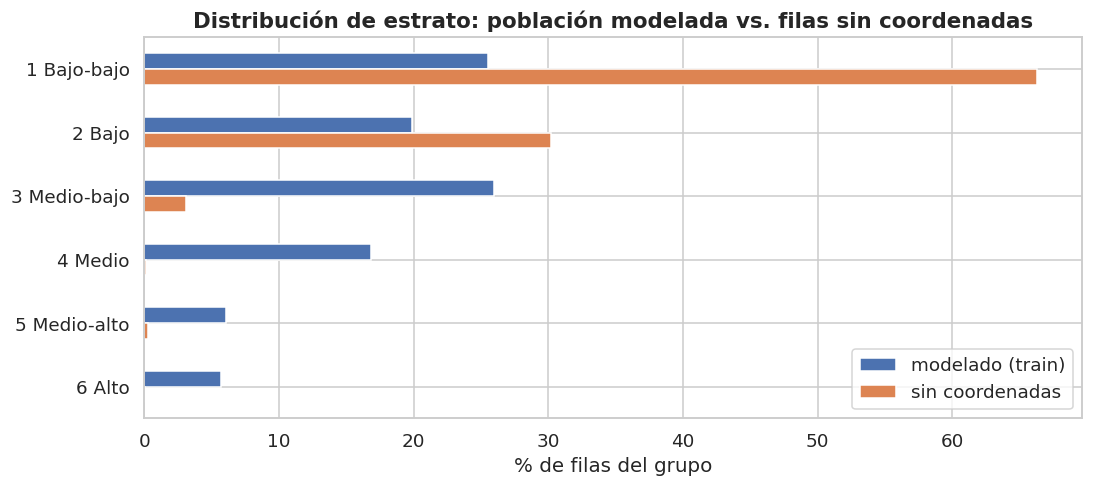

In [11]:
# Barras pareadas del % de cada estrato en la población modelada (azul) y en las
# filas sin coordenadas (naranja): visualiza el sesgo de cobertura hacia estratos bajos.
fig, ax = plt.subplots(figsize=(11, 4.5))
comp.plot.barh(ax=ax, color=["#4c72b0", "#dd8452"])
ax.invert_yaxis()   # estrato 1 arriba, 6 abajo
ax.set_xlabel("% de filas del grupo")
ax.set_title("Distribución de estrato: población modelada vs. filas sin coordenadas")
G.guardar(fig, "03_sesgo_cobertura")
plt.show()

```{admonition} Interpretación
:class: important
- El sesgo de cobertura es **fuerte**: de las filas sin coordenadas, el
  **66.3 % son estrato 1 y el 30.2 % estrato 2** (96.5 % en los dos estratos
  más bajos), frente a 25.5 % y 19.9 % en la población modelada. La V de
  Cramér entre "tener o no coordenadas" y el estrato es **0.42**, una
  asociación grande.
- La razón es estructural: el **99.5 %** de las filas sin coordenadas son
  predios `Informal` (sin lote propio ni edificio matriz de donde tomar un
  centroide). En train, lo informal pesa solo 7.6 %.
- Consecuencia: el modelo representa la **ciudad formal**. Aprenderá del
  estrato 1 sobre todo su versión formal, y sus métricas no deben
  extrapolarse a asentamientos informales. Se declara como limitación en las
  conclusiones. Mejora futura: ubicar estos predios con otra fuente
  (cartografía de manzanas o geocodificación de direcciones) o con el código
  de sector/barrio del NPN.
```